In [3]:
import pandas as pd
import plotly.express as px
import os

# 1. Define file path (assuming it is in the same folder as this script)
file_name = "time_series.csv"

if not os.path.exists(file_name):
    print(f"Error: Could not find '{file_name}' in the current directory.")
    print("Please make sure your CSV file is in the same folder as this script.")
else:
    print(f"Successfully located {file_name}. Processing data...")

    # 2. Load the dataset
    df = pd.read_csv(file_name)

    # 3. Clean the 'Value' column
    # UNHCR data uses '*' to protect identity for small numbers (1-4). 
    # We replace it with '2' (an average estimate) or '0' so Python can treat it as a number.
    df['Value'] = df['Value'].replace('*', '2')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce').fillna(0)

    # 4. Aggregate data globally by Year and Population Type
    # This groups millions of rows into a clean summary over time
    summary_df = df.groupby(['Year', 'Population type'])['Value'].sum().reset_index()

    # 5. Create an Interactive Stacked Area Chart
    fig = px.area(
        summary_df, 
        x='Year', 
        y='Value', 
        color='Population type',
        title='Global Trends of Populations of Concern (UNHCR Data)',
        labels={'Value': 'Total Number of People', 'Year': 'Year'},
        template='plotly_white' # Clean visual background
    )

    # Improve layout styling
    fig.update_layout(
        xaxis_title="Year",
        yaxis_title="Total Population",
        legend_title="Population Category",
        hovermode="x unified" # Shows all categories simultaneously when hovering
    )

    # 6. Display the graph
    print("Opening the graph in your browser...")
    fig.show()

Successfully located time_series.csv. Processing data...


C:\Users\Kien computer\AppData\Local\Temp\ipykernel_11120\3171416087.py:15: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name)


Opening the graph in your browser...


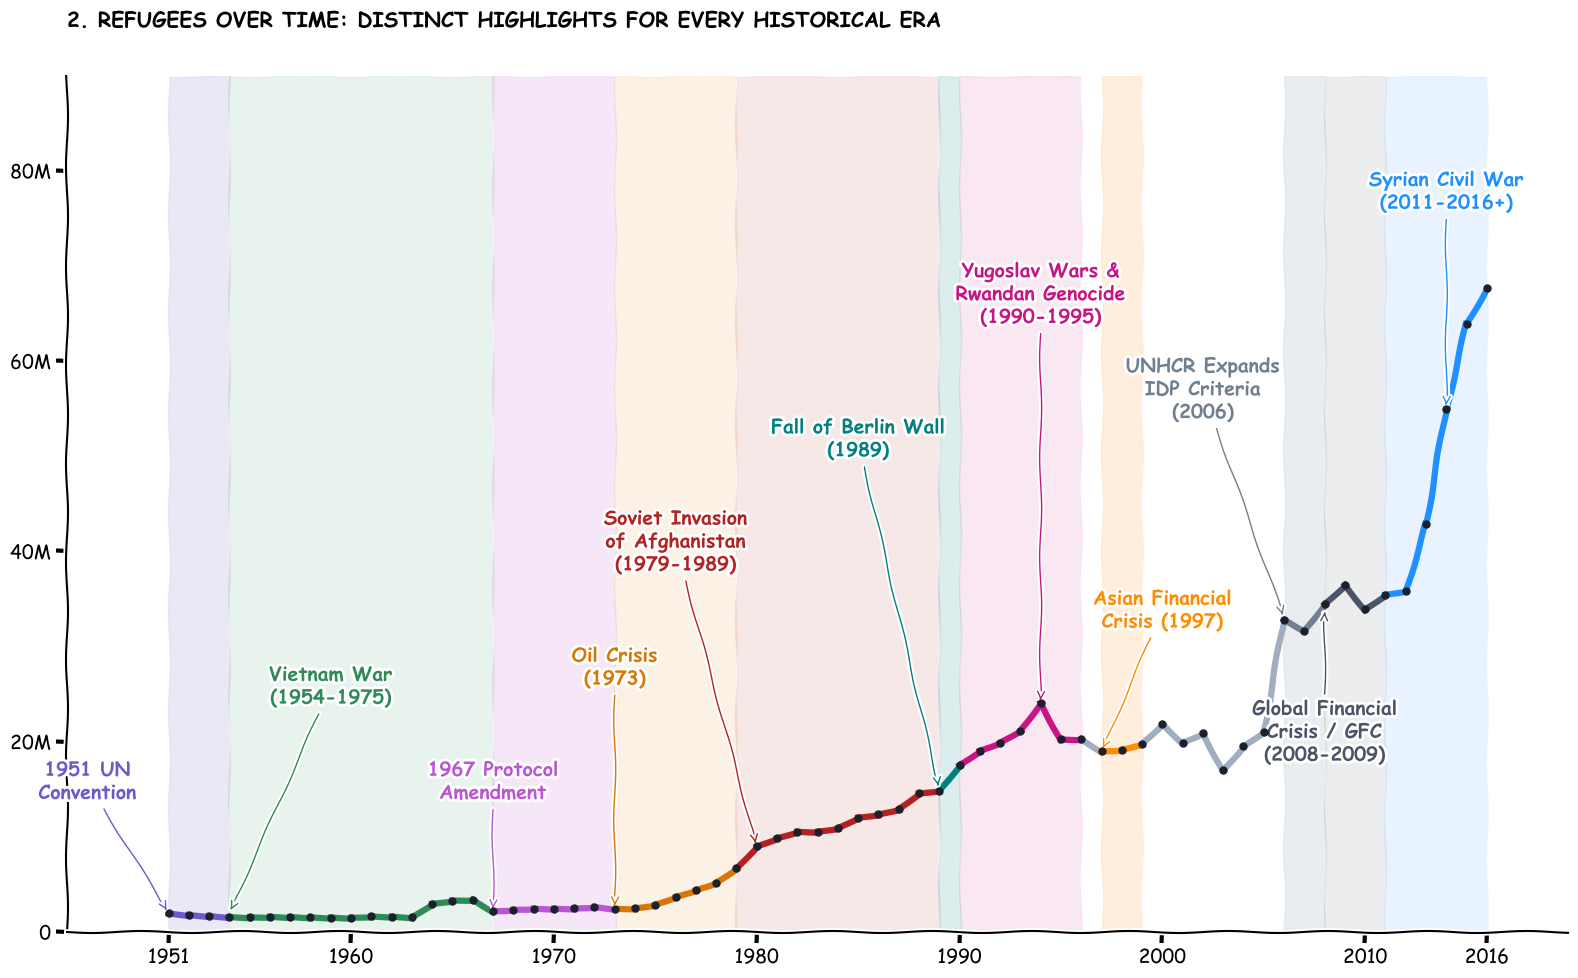

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import logging

# 1. Prevent system font manager log messages from polluting the VS Code output
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Load and Clean the dataset
file_name = 'time_series.csv'
df = pd.read_csv(file_name, low_memory=False)
df['Value'] = df['Value'].replace('*', '2')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce').fillna(0)

# 3. Aggregate data globally by Year
summary_df = df.groupby('Year')['Value'].sum().reset_index()
summary_df['Value_M'] = summary_df['Value'] / 1e6

# 4. Use standard cross-platform system fonts for clean xkcd sketchy styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Comic Sans MS', 'Arial']

# 5. Define the Explicit Color Mapping for Each Event
color_map = {
    '1951-1953': '#6A5ACD',  # Slate Blue
    '1954-1966': '#2E8B57',  # Sea Green
    '1967-1972': '#BA55D3',  # Medium Orchid
    '1973-1978': '#D97706',  # Amber
    '1979-1988': '#B22222',  # Firebrick Red
    '1989':      '#008080',  # Teal
    '1990-1995': '#C71585',  # Deep Magenta
    '1997':      '#FF8C00',  # Dark Orange
    '2006-2007': '#708090',  # Slate Gray
    '2008-2010': '#4A5568',  # Charcoal
    '2011-2016': '#1E90FF',  # Dodger Blue
    'default':   '#A0AEC0'   # Light Baseline Gray
}

with plt.xkcd(scale=1, length=100, randomness=1.2):
    fig, ax = plt.subplots(figsize=(16, 10))
    
    years = summary_df['Year'].values
    vals = summary_df['Value_M'].values
    
    # 6. Apply individual colors section-by-section across the timeline line string
    for i in range(len(years) - 1):
        y1, y2 = years[i], years[i+1]
        v1, v2 = vals[i], vals[i+1]
        
        if 1951 <= y1 < 1954:    c = color_map['1951-1953']
        elif 1954 <= y1 < 1967:  c = color_map['1954-1966']
        elif 1967 <= y1 < 1973:  c = color_map['1967-1972']
        elif 1973 <= y1 < 1979:  c = color_map['1973-1978']
        elif 1979 <= y1 < 1989:  c = color_map['1979-1988']
        elif y1 == 1989:         c = color_map['1989']
        elif 1990 <= y1 < 1996:  c = color_map['1990-1995']
        elif 1996 <= y1 < 2006:
            c = color_map['1997'] if (y1 == 1997 or y1 == 1998) else color_map['default']
        elif 2006 <= y1 < 2008:  c = color_map['2006-2007']
        elif 2008 <= y1 < 2011:  c = color_map['2008-2010']
        elif 2011 <= y1 <= 2016: c = color_map['2011-2016']
        else:                    c = color_map['default']
            
        ax.plot([y1, y2], [v1, v2], color=c, lw=4.5, zorder=3)

    # 7. Paint matching low-opacity background columns to frame durations perfectly
    ax.axvspan(1951, 1954, color=color_map['1951-1953'], alpha=0.07)
    ax.axvspan(1954, 1967, color=color_map['1954-1966'], alpha=0.05)
    ax.axvspan(1967, 1973, color=color_map['1967-1972'], alpha=0.07)
    ax.axvspan(1973, 1979, color=color_map['1973-1978'], alpha=0.05)
    ax.axvspan(1979, 1989, color=color_map['1979-1988'], alpha=0.05)
    ax.axvspan(1989, 1990, color=color_map['1989'], alpha=0.07)
    ax.axvspan(1990, 1996, color=color_map['1990-1995'], alpha=0.05)
    ax.axvspan(1997, 1999, color=color_map['1997'], alpha=0.07)
    ax.axvspan(2006, 2008, color=color_map['2006-2007'], alpha=0.07)
    ax.axvspan(2008, 2011, color=color_map['2008-2010'], alpha=0.05)
    ax.axvspan(2011, 2016, color=color_map['2011-2016'], alpha=0.05)

    # Anchor dots
    ax.scatter(years, vals, color='#1A202C', s=25, zorder=4)

    # 8. Annotations explicitly inheriting their matching contextual colors
    ax.annotate('1951 UN\nConvention', xy=(1951, 2), xytext=(1947, 14), arrowprops=dict(arrowstyle="->", color=color_map['1951-1953']), color=color_map['1951-1953'], ha='center', fontweight='bold')
    ax.annotate('Vietnam War\n(1954-1975)', xy=(1954, 2), xytext=(1959, 24), arrowprops=dict(arrowstyle="->", color=color_map['1954-1966']), color=color_map['1954-1966'], ha='center', fontweight='bold')
    ax.annotate('1967 Protocol\nAmendment', xy=(1967, 2.1), xytext=(1967, 14), arrowprops=dict(arrowstyle="->", color=color_map['1967-1972']), color=color_map['1967-1972'], ha='center', fontweight='bold')
    ax.annotate('Oil Crisis\n(1973)', xy=(1973, 2.4), xytext=(1973, 26), arrowprops=dict(arrowstyle="->", color=color_map['1973-1978']), color=color_map['1973-1978'], ha='center', fontweight='bold')
    ax.annotate('Soviet Invasion\nof Afghanistan\n(1979-1989)', xy=(1980, 9), xytext=(1976, 38), arrowprops=dict(arrowstyle="->", color=color_map['1979-1988']), color=color_map['1979-1988'], ha='center', fontweight='bold')
    ax.annotate('Fall of Berlin Wall\n(1989)', xy=(1989, 15), xytext=(1985, 50), arrowprops=dict(arrowstyle="->", color=color_map['1989']), color=color_map['1989'], ha='center', fontweight='bold')
    ax.annotate('Yugoslav Wars &\nRwandan Genocide\n(1990-1995)', xy=(1994, 24), xytext=(1994, 64), arrowprops=dict(arrowstyle="->", color=color_map['1990-1995']), color=color_map['1990-1995'], ha='center', fontweight='bold')
    ax.annotate('Asian Financial\nCrisis (1997)', xy=(1997, 19), xytext=(2000, 32), arrowprops=dict(arrowstyle="->", color=color_map['1997']), color=color_map['1997'], ha='center', fontweight='bold')
    ax.annotate('UNHCR Expands\nIDP Criteria\n(2006)', xy=(2006, 33), xytext=(2002, 54), arrowprops=dict(arrowstyle="->", color=color_map['2006-2007']), color=color_map['2006-2007'], ha='center', fontweight='bold')
    ax.annotate('Global Financial\nCrisis / GFC\n(2008-2009)', xy=(2008, 34), xytext=(2008, 18), arrowprops=dict(arrowstyle="->", color=color_map['2008-2010']), color=color_map['2008-2010'], ha='center', fontweight='bold')
    ax.annotate('Syrian Civil War\n(2011-2016+)', xy=(2014, 55), xytext=(2014, 76), arrowprops=dict(arrowstyle="->", color=color_map['2011-2016']), color=color_map['2011-2016'], ha='center', fontweight='bold')

    # Formatting axis boundaries and layout cleanup
    ax.set_title("2. REFUGEES OVER TIME: DISTINCT HIGHLIGHTS FOR EVERY HISTORICAL ERA", loc='left', fontsize=15, pad=35, fontweight='bold')
    ax.set_xlim(1946, 2020)
    ax.set_ylim(0, 90)
    
    ax.set_yticks([0, 20, 40, 60, 80])
    ax.set_yticklabels(['0', '20M', '40M', '60M', '80M'])
    ax.set_xticks([1951, 1960, 1970, 1980, 1990, 2000, 2010, 2016])
    ax.set_xticklabels(['1951', '1960', '1970', '1980', '1990', '2000', '2010', '2016'])
    
    # Hide top and right framing lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

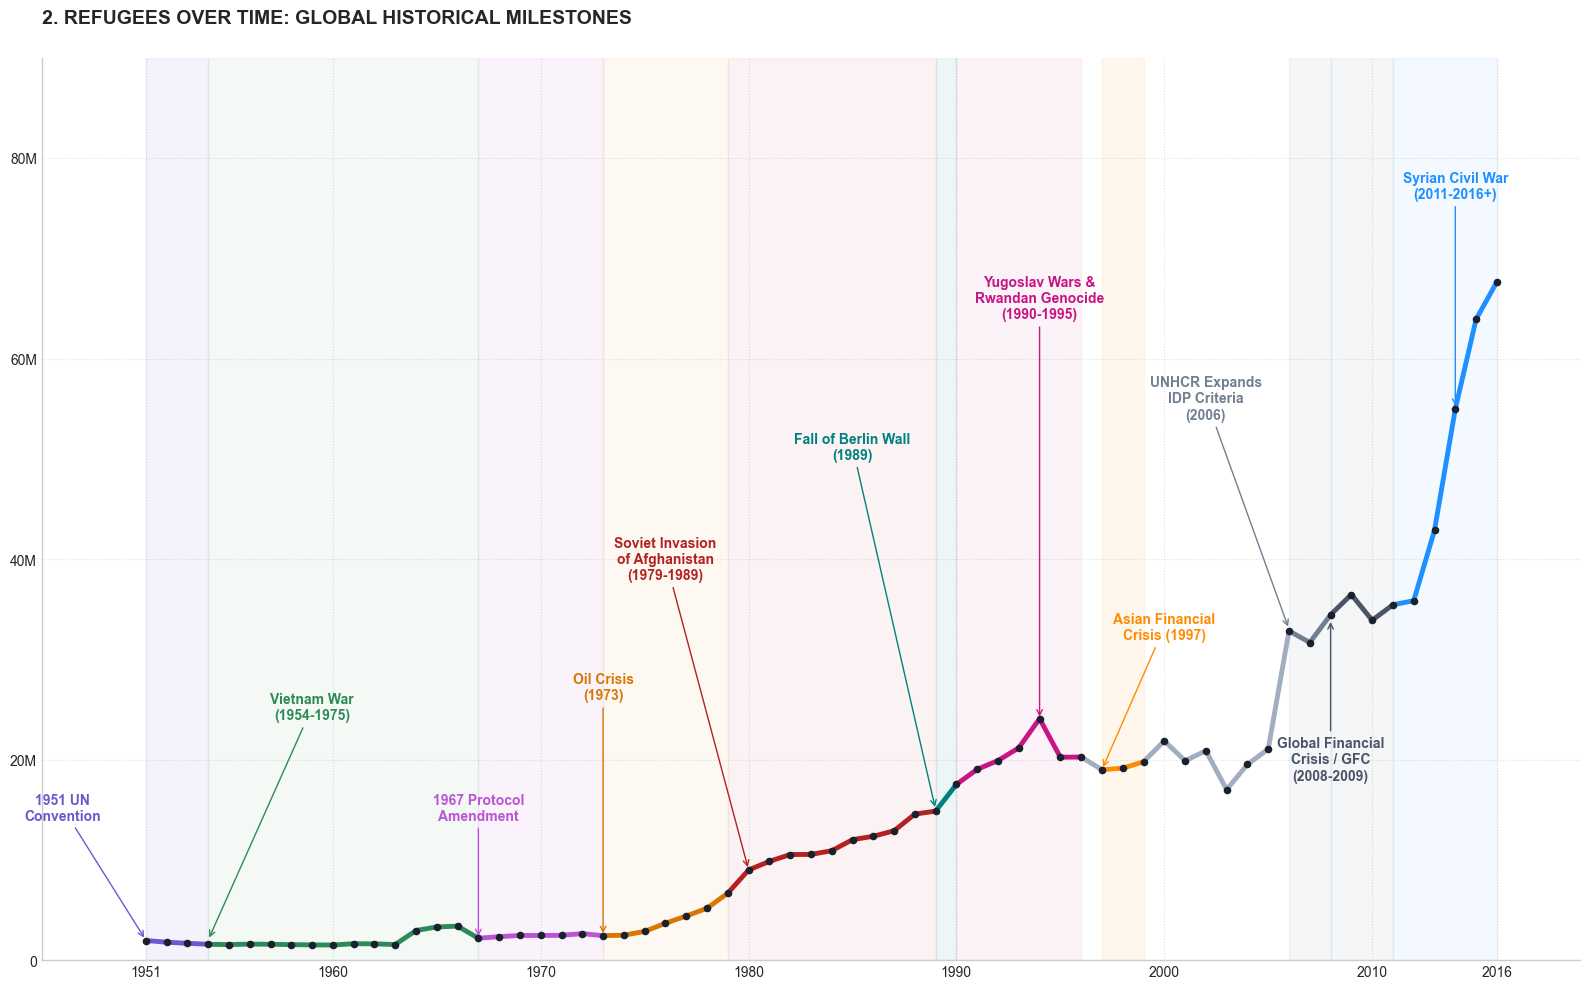

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import logging

# 1. Prevent system font manager messages from polluting the VS Code output
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. Load and Clean the dataset
file_name = 'time_series.csv'
df = pd.read_csv(file_name, low_memory=False)
df['Value'] = df['Value'].replace('*', '2')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce').fillna(0)

# 3. Aggregate data globally by Year
summary_df = df.groupby('Year')['Value'].sum().reset_index()
summary_df['Value_M'] = summary_df['Value'] / 1e6

# 4. Initialize clean, modern styling parameters
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(16, 10))

# 5. Define Explicit Distinct Color Mappings
color_map = {
    '1951-1953': '#6A5ACD',  # Slate Blue
    '1954-1966': '#2E8B57',  # Sea Green
    '1967-1972': '#BA55D3',  # Medium Orchid
    '1973-1978': '#D97706',  # Amber
    '1979-1988': '#B22222',  # Firebrick Red
    '1989':      '#008080',  # Teal
    '1990-1995': '#C71585',  # Deep Magenta
    '1997':      '#FF8C00',  # Dark Orange
    '2006-2007': '#708090',  # Slate Gray
    '2008-2010': '#4A5568',  # Charcoal
    '2011-2016': '#1E90FF',  # Dodger Blue
    'default':   '#A0AEC0'   # Light Baseline Gray
}

years = summary_df['Year'].values
vals = summary_df['Value_M'].values

# 6. Draw piece-wise straight line path segments with their custom color codes
for i in range(len(years) - 1):
    y1, y2 = years[i], years[i+1]
    v1, v2 = vals[i], vals[i+1]
    
    if 1951 <= y1 < 1954:    c = color_map['1951-1953']
    elif 1954 <= y1 < 1967:  c = color_map['1954-1966']
    elif 1967 <= y1 < 1973:  c = color_map['1967-1972']
    elif 1973 <= y1 < 1979:  c = color_map['1973-1978']
    elif 1979 <= y1 < 1989:  c = color_map['1979-1988']
    elif y1 == 1989:         c = color_map['1989']
    elif 1990 <= y1 < 1996:  c = color_map['1990-1995']
    elif 1996 <= y1 < 2006:
        c = color_map['1997'] if (y1 == 1997 or y1 == 1998) else color_map['default']
    elif 2006 <= y1 < 2008:  c = color_map['2006-2007']
    elif 2008 <= y1 < 2011:  c = color_map['2008-2010']
    elif 2011 <= y1 <= 2016: c = color_map['2011-2016']
    else:                    c = color_map['default']
        
    ax.plot([y1, y2], [v1, v2], color=c, lw=3.5, zorder=3)

# 7. Add professional low-opacity background columns to capture full event durations
ax.axvspan(1951, 1954, color=color_map['1951-1953'], alpha=0.07)
ax.axvspan(1954, 1967, color=color_map['1954-1966'], alpha=0.05)
ax.axvspan(1967, 1973, color=color_map['1967-1972'], alpha=0.07)
ax.axvspan(1973, 1979, color=color_map['1973-1978'], alpha=0.05)
ax.axvspan(1979, 1989, color=color_map['1979-1988'], alpha=0.05)
ax.axvspan(1989, 1990, color=color_map['1989'], alpha=0.07)
ax.axvspan(1990, 1996, color=color_map['1990-1995'], alpha=0.05)
ax.axvspan(1997, 1999, color=color_map['1997'], alpha=0.07)
ax.axvspan(2006, 2008, color=color_map['2006-2007'], alpha=0.07)
ax.axvspan(2008, 2011, color=color_map['2008-2010'], alpha=0.05)
ax.axvspan(2011, 2016, color=color_map['2011-2016'], alpha=0.05)

# Place clean point anchors
ax.scatter(years, vals, color='#1A202C', s=20, zorder=4)

# 8. High-contrast labels synced with matching segment colors
ax.annotate('1951 UN\nConvention', xy=(1951, 2), xytext=(1947, 14), arrowprops=dict(arrowstyle="->", color=color_map['1951-1953']), color=color_map['1951-1953'], ha='center', fontweight='bold')
ax.annotate('Vietnam War\n(1954-1975)', xy=(1954, 2), xytext=(1959, 24), arrowprops=dict(arrowstyle="->", color=color_map['1954-1966']), color=color_map['1954-1966'], ha='center', fontweight='bold')
ax.annotate('1967 Protocol\nAmendment', xy=(1967, 2.1), xytext=(1967, 14), arrowprops=dict(arrowstyle="->", color=color_map['1967-1972']), color=color_map['1967-1972'], ha='center', fontweight='bold')
ax.annotate('Oil Crisis\n(1973)', xy=(1973, 2.4), xytext=(1973, 26), arrowprops=dict(arrowstyle="->", color=color_map['1973-1978']), color=color_map['1973-1978'], ha='center', fontweight='bold')
ax.annotate('Soviet Invasion\nof Afghanistan\n(1979-1989)', xy=(1980, 9), xytext=(1976, 38), arrowprops=dict(arrowstyle="->", color=color_map['1979-1988']), color=color_map['1979-1988'], ha='center', fontweight='bold')
ax.annotate('Fall of Berlin Wall\n(1989)', xy=(1989, 15), xytext=(1985, 50), arrowprops=dict(arrowstyle="->", color=color_map['1989']), color=color_map['1989'], ha='center', fontweight='bold')
ax.annotate('Yugoslav Wars &\nRwandan Genocide\n(1990-1995)', xy=(1994, 24), xytext=(1994, 64), arrowprops=dict(arrowstyle="->", color=color_map['1990-1995']), color=color_map['1990-1995'], ha='center', fontweight='bold')
ax.annotate('Asian Financial\nCrisis (1997)', xy=(1997, 19), xytext=(2000, 32), arrowprops=dict(arrowstyle="->", color=color_map['1997']), color=color_map['1997'], ha='center', fontweight='bold')
ax.annotate('UNHCR Expands\nIDP Criteria\n(2006)', xy=(2006, 33), xytext=(2002, 54), arrowprops=dict(arrowstyle="->", color=color_map['2006-2007']), color=color_map['2006-2007'], ha='center', fontweight='bold')
ax.annotate('Global Financial\nCrisis / GFC\n(2008-2009)', xy=(2008, 34), xytext=(2008, 18), arrowprops=dict(arrowstyle="->", color=color_map['2008-2010']), color=color_map['2008-2010'], ha='center', fontweight='bold')
ax.annotate('Syrian Civil War\n(2011-2016+)', xy=(2014, 55), xytext=(2014, 76), arrowprops=dict(arrowstyle="->", color=color_map['2011-2016']), color=color_map['2011-2016'], ha='center', fontweight='bold')

# Formatting boundaries and layout clean up
ax.set_title("2. REFUGEES OVER TIME: GLOBAL HISTORICAL MILESTONES", loc='left', fontsize=14, pad=25, fontweight='bold')
ax.set_xlim(1946, 2020)
ax.set_ylim(0, 90)

ax.set_yticks([0, 20, 40, 60, 80])
ax.set_yticklabels(['0', '20M', '40M', '60M', '80M'])
ax.set_xticks([1951, 1960, 1970, 1980, 1990, 2000, 2010, 2016])
ax.set_xticklabels(['1951', '1960', '1970', '1980', '1990', '2000', '2010', '2016'])

# Polish spines and structural framework lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
print(demo_df['F: Total'].dtype)
print(demo_df['M: Total'].dtype)

print(demo_df['F: Total'].head())
print(demo_df['M: Total'].head())

object
object
0         2
1    590904
2         1
3      3496
4      1405
Name: F: Total, dtype: object
0         2
1    625720
2         1
3      3063
4      1091
Name: M: Total, dtype: object


In [6]:
bad_female = demo_df[
    pd.to_numeric(demo_df['F: Total'], errors='coerce').isna()
]

print(bad_female[['F: Total']].head(20))

      F: Total
14840        *
14847        *
14857        *
14884        *
14889        *
14975        *
15007        *
15009        *
15013        *
15036        *
15037        *
15041        *
15042        *
15043        *
15044        *
15048        *
15049        *
15051        *
15057        *
15058        *


In [7]:
demo_df['F: Total'] = (
    demo_df['F: Total']
    .astype(str)
    .str.replace('*', '0', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

demo_df['M: Total'] = (
    demo_df['M: Total']
    .astype(str)
    .str.replace('*', '0', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

demo_df['F: Total'] = pd.to_numeric(
    demo_df['F: Total'],
    errors='coerce'
).fillna(0)

demo_df['M: Total'] = pd.to_numeric(
    demo_df['M: Total'],
    errors='coerce'
).fillna(0)

In [12]:
print(demo_df['F: Total'].dtype)
print(demo_df['M: Total'].dtype)

object
object


In [13]:
demo_df['F: Total'] = pd.to_numeric(
    demo_df['F: Total']
        .astype(str)
        .str.replace('*', '0', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip(),
    errors='coerce'
).fillna(0)

demo_df['M: Total'] = pd.to_numeric(
    demo_df['M: Total']
        .astype(str)
        .str.replace('*', '0', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip(),
    errors='coerce'
).fillna(0)

print(demo_df['F: Total'].dtype)
print(demo_df['M: Total'].dtype)

int64
int64


In [15]:
# =========================================================================
# STEP 2: LOAD AND AGGREGATE DEMOGRAPHICS DATA (demographics.csv)
# =========================================================================

demo_df = pd.read_csv('demographics.csv', low_memory=False)

# Clean column names
demo_df.columns = demo_df.columns.str.strip()

# Columns to convert
numeric_cols = [
    'Female 0-4', 'Female 5-11', 'Female 5-17', 'Female 12-17',
    'Female 18-59', 'Female 60+',
    'Male 0-4', 'Male 5-11', 'Male 5-17', 'Male 12-17',
    'Male 18-59', 'Male 60+',
    'F: Total', 'M: Total'
]

# Clean and convert all demographic columns
for col in numeric_cols:

    if col not in demo_df.columns:
        print(f"WARNING: Column not found -> {col}")
        continue

    demo_df[col] = (
        demo_df[col]
        .astype(str)
        .str.replace('*', '0', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )

    demo_df[col] = pd.to_numeric(
        demo_df[col],
        errors='coerce'
    ).fillna(0)

# Verify conversion
print("\nColumn Types:")
print(demo_df[numeric_cols].dtypes)

# =========================================================================
# AGE BREAKDOWN
# =========================================================================

children_total = (
    demo_df['Female 0-4'].sum() +
    demo_df['Female 5-11'].sum() +
    demo_df['Female 5-17'].sum() +
    demo_df['Female 12-17'].sum() +
    demo_df['Male 0-4'].sum() +
    demo_df['Male 5-11'].sum() +
    demo_df['Male 5-17'].sum() +
    demo_df['Male 12-17'].sum()
)

adult_total = (
    demo_df['Female 18-59'].sum() +
    demo_df['Male 18-59'].sum()
)

elderly_total = (
    demo_df['Female 60+'].sum() +
    demo_df['Male 60+'].sum()
)

demo_totals = {
    'Children (0-17)': children_total,
    'Adults (18-59)': adult_total,
    'Elderly (60+)': elderly_total
}

# =========================================================================
# GENDER BREAKDOWN
# =========================================================================

female_total = float(demo_df['F: Total'].sum())
male_total = float(demo_df['M: Total'].sum())

gender_totals = {
    'Female': female_total,
    'Male': male_total
}

print("\nGender Totals:")
print(gender_totals)

gender_labels = list(gender_totals.keys())
gender_values = list(gender_totals.values())

print("\nGender Values:")
print(gender_values)
print([type(x) for x in gender_values])

# =========================================================================
# PANEL 4: BOTTOM RIGHT - GENDER DISTRIBUTION
# =========================================================================

ax4 = fig.add_subplot(grid[1, 1])

ax4.pie(
    gender_values,
    labels=gender_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ED64A6', '#3182CE'],
    wedgeprops={
        'width': 0.4,
        'edgecolor': '#1A202C'
    }
)

ax4.set_title(
    'Demographic Profile: Gender Split',
    fontsize=12,
    fontweight='bold',
    pad=12
)


Column Types:
Female 0-4      float64
Female 5-11     float64
Female 5-17     float64
Female 12-17    float64
Female 18-59    float64
Female 60+      float64
Male 0-4        float64
Male 5-11       float64
Male 5-17       float64
Male 12-17      float64
Male 18-59      float64
Male 60+        float64
F: Total          int64
M: Total          int64
dtype: object

Gender Totals:
{'Female': 136146430.0, 'Male': 141679150.0}

Gender Values:
[136146430.0, 141679150.0]
[<class 'float'>, <class 'float'>]


Text(0.5, 1.0, 'Demographic Profile: Gender Split')

In [16]:
print(repr(demo_df.columns.tolist()))

['Year', 'Country / territory of asylum/residence', 'Location Name', 'Female 0-4', 'Female 5-11', 'Female 5-17', 'Female 12-17', 'Female 18-59', 'Female 60+', 'F: Unknown', 'F: Total', 'Male 0-4', 'Male 5-11', 'Male 5-17', 'Male 12-17', 'Male 18-59', 'Male 60+', 'M: Unknown', 'M: Total']


In [23]:
import pandas as pd
import plotly.express as px

# 1. Load and prepare the refugee dataset
df_poc = pd.read_csv('persons_of_concern.csv', low_memory=False)
df_2007 = df_poc[df_poc['Year'] == 2007].copy()
df_2007['Refugees'] = pd.to_numeric(df_2007['Refugees (incl. refugee-like situations)'], errors='coerce').fillna(0)

# Group by country
df_host = df_2007.groupby('Country / territory of asylum/residence')['Refugees'].sum().reset_index()
df_host.rename(columns={'Country / territory of asylum/residence': 'country'}, inplace=True)

# 2. Load the population dataset
df_gap = px.data.gapminder()
df_pop_2007 = df_gap[df_gap['year'] == 2007][['country', 'iso_alpha', 'pop']]

# 3. Merge data (Left join to keep all global landmasses visible)
df_merged = pd.merge(df_pop_2007, df_host, on='country', how='left')
df_merged['Refugees'] = df_merged['Refugees'].fillna(0)

# 4. Calculate the metric
df_merged['Refugees_per_100k'] = (df_merged['Refugees'] / df_merged['pop']) * 100000

# 5. Categorize into bins
def categorize_metric(value):
    if pd.isna(value): return 'No data'
    elif value > 2000: return '> 2,000'
    elif value >= 1000: return '1,000 - 2,000'
    elif value >= 250: return '250 - 1,000'
    elif value >= 50: return '50 - 250'
    else: return '< 50'

df_merged['Legend_Category'] = df_merged['Refugees_per_100k'].apply(categorize_metric)

# 6. Format custom hover text using HTML
df_merged['Hover_Text'] = (
    "<b>" + df_merged['country'] + "</b><br><br>" +
    "Refugees: " + df_merged['Refugees'].map('{:,.0f}'.format) + "<br>" +
    "Population: " + df_merged['pop'].map('{:,.0f}'.format) + "<br>" +
    "Rate (per 100k): " + df_merged['Refugees_per_100k'].map('{:,.1f}'.format)
)

# 7. Define a refined, modern color palette
custom_colors = {
    '> 2,000': '#08306b',        # Deep navy blue
    '1,000 - 2,000': '#2879b9',  # Strong blue
    '250 - 1,000': '#73b3d8',    # Mid blue
    '50 - 250': '#c8ddf0',       # Light blue
    '< 50': '#f7fbff',           # Very light blue
    'No data': '#e0e0e0'         # Neutral grey
}

# 8. Generate the Improved Map
fig = px.choropleth(
    df_merged,
    locations="iso_alpha",
    color="Legend_Category",
    color_discrete_map=custom_colors,
    custom_data=["Hover_Text"], 
    title="<b>Global Refugee Density</b><br><sup>Refugees per 100,000 population (2007)</sup>",
    category_orders={"Legend_Category": ['> 2,000', '1,000 - 2,000', '250 - 1,000', '50 - 250', '< 50', 'No data']}
)

# Apply the custom HTML hover template
fig.update_traces(hovertemplate="%{customdata[0]}<extra></extra>")

# 9. Refine the map layout and aesthetics
fig.update_layout(
    geo=dict(
        showframe=False,                 # Remove the bounding box
        showcoastlines=True,
        coastlinecolor='rgba(255, 255, 255, 0.7)', # Subtle white borders
        projection_type='natural earth', # Accurate global projection
        showland=True,
        landcolor='#e0e0e0',             # Base color for missing countries
        showocean=True,
        oceancolor='#f8f9fa',            # Very subtle off-white ocean
        bgcolor='rgba(0,0,0,0)'          # Transparent background
    ),
    legend=dict(
        title="<b>Refugees per 100k</b>",
        yanchor="bottom",
        y=0.1,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#cccccc",
        borderwidth=1
    ),
    font=dict(family="Helvetica, Arial, sans-serif"),
    margin=dict(l=0, r=0, t=80, b=0),    # Maximize the map area
    paper_bgcolor='white',
)

fig.show()

In [25]:
import pandas as pd
import plotly.express as px

# 1. Load the refugee dataset
df_poc = pd.read_csv('persons_of_concern.csv', low_memory=False)

# Clean the refugee data (converting any redacted '*' values to 0)
df_poc['Refugees'] = pd.to_numeric(df_poc['Refugees (incl. refugee-like situations)'], errors='coerce').fillna(0)

# Group total refugees by host country AND Year
df_host = df_poc.groupby(['Year', 'Country / territory of asylum/residence'])['Refugees'].sum().reset_index()
df_host.rename(columns={'Country / territory of asylum/residence': 'country'}, inplace=True)

# 2. Load the built-in population dataset from Plotly (Gapminder)
df_gap = px.data.gapminder()

# 3. Merge data on BOTH 'country' and 'year'
# This ensures we get the population for that specific historical year
df_merged = pd.merge(df_host, df_gap, left_on=['country', 'Year'], right_on=['country', 'year'], how='inner')

# 4. Calculate the metric
df_merged['Refugees_per_100k'] = (df_merged['Refugees'] / df_merged['pop']) * 100000

# 5. Categorize into bins
def categorize_metric(value):
    if pd.isna(value): return 'No data'
    elif value > 2000: return '> 2,000'
    elif value >= 1000: return '1,000 - 2,000'
    elif value >= 250: return '250 - 1,000'
    elif value >= 50: return '50 - 250'
    else: return '< 50'

df_merged['Legend_Category'] = df_merged['Refugees_per_100k'].apply(categorize_metric)

# 6. Sort by Year (Crucial for the slider to play in the correct chronological order)
df_merged = df_merged.sort_values('Year')

# Format custom HTML hover text to include the Year
df_merged['Hover_Text'] = (
    "<b>" + df_merged['country'] + "</b> (" + df_merged['Year'].astype(str) + ")<br><br>" +
    "Refugees: " + df_merged['Refugees'].map('{:,.0f}'.format) + "<br>" +
    "Population: " + df_merged['pop'].map('{:,.0f}'.format) + "<br>" +
    "Rate (per 100k): " + df_merged['Refugees_per_100k'].map('{:,.1f}'.format)
)

custom_colors = {
    '> 2,000': '#08306b',
    '1,000 - 2,000': '#2879b9',
    '250 - 1,000': '#73b3d8',
    '50 - 250': '#c8ddf0',
    '< 50': '#f7fbff',
    'No data': '#e0e0e0'
}

# 7. Generate the Animated Map
fig = px.choropleth(
    df_merged,
    locations="iso_alpha",
    color="Legend_Category",
    color_discrete_map=custom_colors,
    animation_frame="Year",               # <--- THIS CREATES THE TIME SLIDER
    custom_data=["Hover_Text"], 
    title="<b>Global Refugee Density Over Time</b><br><sup>Refugees per 100,000 population</sup>",
    category_orders={"Legend_Category": ['> 2,000', '1,000 - 2,000', '250 - 1,000', '50 - 250', '< 50', 'No data']}
)

# 8. Refine map layout and aesthetics
# 8. Refine map layout and aesthetics
fig.update_traces(hovertemplate="%{customdata[0]}<extra></extra>")

fig.update_layout(
    height=800,  # <--- 1. INCREASE FIGURE HEIGHT (default is around 500)
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='rgba(255, 255, 255, 0.7)',
        projection_type='natural earth',
        projection_scale=1.2,  # <--- 2. ZOOM IN ON THE EARTH (1.0 is default)
        showland=True,
        landcolor='#e0e0e0',
        showocean=True,
        oceancolor='#f8f9fa',
        bgcolor='rgba(0,0,0,0)'
    ),
    legend=dict(
        title="<b>Refugees per 100k</b>",
        yanchor="bottom",
        y=0.1,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#cccccc",
        borderwidth=1
    ),
    font=dict(family="Helvetica, Arial, sans-serif"),
    margin=dict(l=0, r=0, t=80, b=0), # Keeps the edges tight so the earth fills the screen
    paper_bgcolor='white',
)

fig.show()


In [26]:
import pandas as pd
import plotly.express as px
import requests

# 1. Load your local refugee data
print("Loading refugee data...")
df_poc = pd.read_csv('persons_of_concern.csv', low_memory=False)

# Clean and group the data
df_poc['Refugees'] = pd.to_numeric(df_poc['Refugees (incl. refugee-like situations)'], errors='coerce').fillna(0)
df_host = df_poc.groupby(['Year', 'Country / territory of asylum/residence'])['Refugees'].sum().reset_index()
df_host.rename(columns={'Country / territory of asylum/residence': 'Country'}, inplace=True)

# Filter for the years 2000 to 2016
df_host = df_host[(df_host['Year'] >= 2000) & (df_host['Year'] <= 2016)]

# 2. Automatically fetch Population Data from the World Bank API
print("Fetching historical population data from the World Bank...")
url = "https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&date=2000:2016&per_page=10000"
response = requests.get(url).json()

# Parse the API response into a dataset
pop_data = []
for item in response[1]:
    if item['country']['value'] and item['value'] is not None:
        pop_data.append({
            'Country': item['country']['value'],
            'ISO3': item['countryiso3code'],
            'Year': int(item['date']),
            'Population': item['value']
        })

df_pop = pd.DataFrame(pop_data)

# Fix common country name mismatches between UNHCR and World Bank data
name_replacements = {
    'United States of America': 'United States',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Russian Federation': 'Russian Federation', 
    'Venezuela (Bolivarian Republic of)': 'Venezuela, RB',
    'Iran (Islamic Republic of)': 'Iran, Islamic Rep.',
    'Egypt': 'Egypt, Arab Rep.',
    'Democratic Republic of the Congo': 'Congo, Dem. Rep.'
}
df_host['Country'] = df_host['Country'].replace(name_replacements)

# 3. Merge datasets
print("Merging data and calculating metrics...")
df_merged = pd.merge(df_host, df_pop, on=['Country', 'Year'], how='inner')

# 4. Calculate the metric
df_merged['Refugees_per_100k'] = (df_merged['Refugees'] / df_merged['Population']) * 100000

# 5. Categorize into bins
def categorize_metric(value):
    if pd.isna(value): return 'No data'
    elif value > 2000: return '> 2,000'
    elif value >= 1000: return '1,000 - 2,000'
    elif value >= 250: return '250 - 1,000'
    elif value >= 50: return '50 - 250'
    else: return '< 50'

df_merged['Legend_Category'] = df_merged['Refugees_per_100k'].apply(categorize_metric)
df_merged = df_merged.sort_values('Year')

# 6. Format map tooltips
df_merged['Hover_Text'] = (
    "<b>" + df_merged['Country'] + "</b> (" + df_merged['Year'].astype(str) + ")<br><br>" +
    "Refugees: " + df_merged['Refugees'].map('{:,.0f}'.format) + "<br>" +
    "Population: " + df_merged['Population'].map('{:,.0f}'.format) + "<br>" +
    "Rate (per 100k): " + df_merged['Refugees_per_100k'].map('{:,.1f}'.format)
)

custom_colors = {
    '> 2,000': '#08306b',
    '1,000 - 2,000': '#2879b9',
    '250 - 1,000': '#73b3d8',
    '50 - 250': '#c8ddf0',
    '< 50': '#f7fbff',
    'No data': '#e0e0e0'
}

# 7. Generate the Animated Map
print("Generating interactive map...")
fig = px.choropleth(
    df_merged,
    locations="ISO3",  # Plotly maps the boundaries perfectly using World Bank ISO codes
    color="Legend_Category",
    color_discrete_map=custom_colors,
    animation_frame="Year",
    custom_data=["Hover_Text"], 
    title="<b>Global Refugee Density (2000-2016)</b><br><sup>Refugees per 100,000 population</sup>",
    category_orders={"Legend_Category": ['> 2,000', '1,000 - 2,000', '250 - 1,000', '50 - 250', '< 50', 'No data']}
)

fig.update_traces(hovertemplate="%{customdata[0]}<extra></extra>")
fig.update_layout(
    height=800,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='rgba(255, 255, 255, 0.7)',
        projection_type='natural earth',
        projection_scale=1.2,
        showland=True,
        landcolor='#e0e0e0',
        showocean=True,
        oceancolor='#f8f9fa',
        bgcolor='rgba(0,0,0,0)'
    ),
    legend=dict(
        title="<b>Refugees per 100k</b>",
        yanchor="bottom",
        y=0.1,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#cccccc",
        borderwidth=1
    ),
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

Loading refugee data...
Fetching historical population data from the World Bank...
Merging data and calculating metrics...
Generating interactive map...


In [2]:
import pandas as pd
import plotly.express as px
import requests
import country_converter as coco  # <-- Import the new tool

print("Loading refugee data...")
df_poc = pd.read_csv('persons_of_concern.csv', low_memory=False)

df_poc['Refugees'] = pd.to_numeric(df_poc['Refugees (incl. refugee-like situations)'], errors='coerce').fillna(0)
df_host = df_poc.groupby(['Year', 'Country / territory of asylum/residence'])['Refugees'].sum().reset_index()
df_host.rename(columns={'Country / territory of asylum/residence': 'Country'}, inplace=True)
df_host = df_host[(df_host['Year'] >= 2000) & (df_host['Year'] <= 2016)]

# 1. NEW STEP: Convert messy UN country names to standard ISO-3 codes
print("Standardizing country names...")
df_host['ISO3'] = coco.convert(names=df_host['Country'], to='ISO3', not_found=None)

print("Fetching historical population data from the World Bank...")
url = "https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&date=2000:2016&per_page=10000"
response = requests.get(url).json()

pop_data = []
for item in response[1]:
    if item['country']['value'] and item['value'] is not None:
        pop_data.append({
            'WorldBank_Name': item['country']['value'],
            'ISO3': item['countryiso3code'], # The World Bank already provides ISO codes!
            'Year': int(item['date']),
            'Population': item['value']
        })

df_pop = pd.DataFrame(pop_data)

# 2. NEW STEP: Merge using the ISO3 codes instead of the spelling of the country!
print("Merging data...")
df_merged = pd.merge(df_host, df_pop, on=['ISO3', 'Year'], how='inner')

# Calculate the metric
df_merged['Refugees_per_100k'] = (df_merged['Refugees'] / df_merged['Population']) * 100000

# Categorize into bins
def categorize_metric(value):
    if pd.isna(value): return 'No data'
    elif value > 2000: return '> 2,000'
    elif value >= 1000: return '1,000 - 2,000'
    elif value >= 250: return '250 - 1,000'
    elif value >= 50: return '50 - 250'
    else: return '< 50'

df_merged['Legend_Category'] = df_merged['Refugees_per_100k'].apply(categorize_metric)
df_merged = df_merged.sort_values('Year')

# Format map tooltips
df_merged['Hover_Text'] = (
    "<b>" + df_merged['Country'] + "</b> (" + df_merged['Year'].astype(str) + ")<br><br>" +
    "Refugees: " + df_merged['Refugees'].map('{:,.0f}'.format) + "<br>" +
    "Population: " + df_merged['Population'].map('{:,.0f}'.format) + "<br>" +
    "Rate (per 100k): " + df_merged['Refugees_per_100k'].map('{:,.1f}'.format)
)

custom_colors = {
    '> 2,000': '#08306b',
    '1,000 - 2,000': '#2879b9',
    '250 - 1,000': '#73b3d8',
    '50 - 250': '#c8ddf0',
    '< 50': '#f7fbff',
    'No data': '#e0e0e0'
}

print("Generating interactive map...")
fig = px.choropleth(
    df_merged,
    locations="ISO3", 
    color="Legend_Category",
    color_discrete_map=custom_colors,
    animation_frame="Year",
    custom_data=["Hover_Text"], 
    title="<b>Global Refugee Density (2000-2016)</b><br><sup>Refugees per 100,000 population</sup>",
    category_orders={"Legend_Category": ['> 2,000', '1,000 - 2,000', '250 - 1,000', '50 - 250', '< 50', 'No data']}
)

fig.update_traces(hovertemplate="%{customdata[0]}<extra></extra>")
fig.update_layout(
    height=800,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='rgba(255, 255, 255, 0.7)',
        projection_type='natural earth',
        projection_scale=1.2,
        showland=True,
        landcolor='#e0e0e0',
        showocean=True,
        oceancolor='#f8f9fa',
        bgcolor='rgba(0,0,0,0)'
    ),
    legend=dict(
        title="<b>Refugees per 100k</b>",
        yanchor="bottom",
        y=0.1,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(255, 255, 255, 0.9)",
        bordercolor="#cccccc",
        borderwidth=1
    ),
    margin=dict(l=0, r=0, t=80, b=0)
)

fig.show()

Loading refugee data...
Standardizing country names...


More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expression match for Serbia and Kosovo (S/RES/1244 (1999))
More than one regular expres

Fetching historical population data from the World Bank...
Merging data...


TypeError: unhashable type: 'list'

In [1]:
pip install country_converter


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
